In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/processed/deploypilot_ai_ci_cd_pipeline_dataset.csv")

In [3]:
failure_df = df[df['result'] == 'FAIL'].copy()

In [4]:
type(failure_df)

pandas.DataFrame

In [5]:
failure_df.head()

,pipeline_id,run_id,timestamp,ci_tool,repository,branch,commit_hash,author,language,os,...,retry_count,is_flaky_test,rollback_triggered,incident_created,result,commit_size,files_changed,warnings,tests_failed,previous_failure_rate
0,ado-feature-store-nightly-regression,20260619.24,2026-04-28T22:44:00,Azure DevOps,mlops/feature-store,develop,b61ba350873af319212adfadb5dc5a6dfd856d83,akash_mlops,Python,windows-latest,...,0,False,False,False,FAIL,3,7,2,0,0.207
1,jenkins-e2e-test-suite-release,e2e-test-suite/feature-pagos#22855,2026-04-17T06:51:00,Jenkins,qa/e2e-test-suite,feature/pagos,99568baae90d2f0893079353e02d580f9f454ef2,data_pipeline_bot,C++,ubuntu-latest,...,3,False,False,False,FAIL,62,22,24,0,0.309
2,gha-analytics-etl-build-test-deploy,118001076740-1,2026-04-25T16:49:00,GitHub Actions,data/analytics-etl,release/2026.07,2d023683742031c29712d7960be4e9ddc2d1533f,data_pipeline_bot,Go,windows-latest,...,0,False,False,False,FAIL,11,5,0,0,0.093
4,jenkins-deploypilot-ai-deploy-staging,deploypilot-ai/bugfix-flaky-login-test#30551,2026-05-12T01:32:00,Jenkins,devops/deploypilot-ai,bugfix/flaky-login-test,bb4190851815f62664fa796aa525e364b001004b,nimal_backend,C++,macos-latest,...,3,False,False,True,FAIL,35,11,3,0,0.821
6,jenkins-ml-training-pipeline-ci,ml-training-pipeline/feature-model-registry#29524,2026-05-01T04:17:00,Jenkins,mlops/ml-training-pipeline,feature/model-registry,b1ccd9c5192afee15c437063659ae62063cf53e9,carlos_dev,Rust,windows-latest,...,1,False,False,False,FAIL,36,37,3,0,0.438


In [6]:
failure_df.tail()

,pipeline_id,run_id,timestamp,ci_tool,repository,branch,commit_hash,author,language,os,...,retry_count,is_flaky_test,rollback_triggered,incident_created,result,commit_size,files_changed,warnings,tests_failed,previous_failure_rate
19991,circleci-energy-forecasting-pipeline-deploy-st...,6202d886-3b9e-5084-8261-e0b4f7143251,2026-04-10T02:19:00,CircleCI,mlops/energy-forecasting-pipeline,feature/auth-jwt,237ba55d46af5519c981ad3b42bc43d59ac82609,sara_platform,Java,macos-latest,...,0,False,False,False,FAIL,39,15,5,0,0.279
19992,circleci-order-fulfillment-service-build-test-...,f1606fba-8236-5107-9c1c-e1def3abb051,2026-03-31T09:39:00,CircleCI,commerce/order-fulfillment-service,release/2026.07,5552cb1df438e2c647a0dd24cb479d9876b6642b,nimal_backend,Java,self-hosted-linux,...,1,False,False,False,FAIL,86,38,13,0,0.437
19996,circleci-order-fulfillment-service-pr-validation,4a6c3a0a-6ef1-57d5-9aaa-96782506e51f,2026-05-16T16:54:00,CircleCI,commerce/order-fulfillment-service,feature/order-events,37b1264e619ac1ed4e1a75ef4ca665cdc7e16351,akash_mlops,Java,macos-latest,...,0,False,False,False,FAIL,33,2,4,0,0.355
19997,gha-helm-charts-ci,118001023698-3,2026-06-07T20:00:00,GitHub Actions,infra/helm-charts,release/2026.06,cbe461e2e98ffa2d6b073564d2e03dc61829c46c,devops-bot,NodeJS,ubuntu-latest,...,1,False,False,False,FAIL,25,42,1,0,0.794
19998,gha-reporting-dashboard-build-test-deploy,118000839811-1,2026-04-24T00:11:00,GitHub Actions,reporting/reporting-dashboard,release/2026.07,c99ad98ccf66df6ffecd01e78baf2368394008b6,data_pipeline_bot,Python,ubuntu-latest,...,3,False,False,False,FAIL,88,29,19,0,0.638


In [7]:
failure_df.shape

(10000, 31)

In [8]:
failure_df.columns

Index(['pipeline_id', 'run_id', 'timestamp', 'ci_tool', 'repository', 'branch',
       'commit_hash', 'author', 'language', 'os', 'cloud_provider',
       'build_duration_sec', 'test_duration_sec', 'deploy_duration_sec',
       'failure_stage', 'failure_type', 'error_code', 'error_message',
       'severity', 'cpu_usage_pct', 'memory_usage_mb', 'retry_count',
       'is_flaky_test', 'rollback_triggered', 'incident_created', 'result',
       'commit_size', 'files_changed', 'warnings', 'tests_failed',
       'previous_failure_rate'],
      dtype='str')

In [9]:
failure_df.info()

<class 'pandas.DataFrame'>
Index: 10000 entries, 0 to 19998
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   pipeline_id            10000 non-null  str    
 1   run_id                 10000 non-null  str    
 2   timestamp              10000 non-null  str    
 3   ci_tool                10000 non-null  str    
 4   repository             10000 non-null  str    
 5   branch                 10000 non-null  str    
 6   commit_hash            10000 non-null  str    
 7   author                 10000 non-null  str    
 8   language               10000 non-null  str    
 9   os                     10000 non-null  str    
 10  cloud_provider         9636 non-null   str    
 11  build_duration_sec     10000 non-null  int64  
 12  test_duration_sec      10000 non-null  int64  
 13  deploy_duration_sec    10000 non-null  int64  
 14  failure_stage          10000 non-null  str    
 15  failure_type      

In [10]:
failure_df.isnull().sum()

pipeline_id                0
run_id                     0
timestamp                  0
ci_tool                    0
repository                 0
branch                     0
commit_hash                0
author                     0
language                   0
os                         0
cloud_provider           364
build_duration_sec         0
test_duration_sec          0
deploy_duration_sec        0
failure_stage              0
failure_type               0
error_code                 0
error_message              0
severity                   0
cpu_usage_pct              0
memory_usage_mb            0
retry_count                0
is_flaky_test              0
rollback_triggered         0
incident_created           0
result                     0
commit_size                0
files_changed              0
warnings                   0
tests_failed               0
previous_failure_rate      0
dtype: int64

In [11]:
failure_df.duplicated().sum()

np.int64(0)

In [12]:
failure_df['failure_type'].value_counts()

failure_type
Configuration Error      1000
Security Scan Failure    1000
Dependency Error         1000
Network Error            1000
Permission Error         1000
Resource Exhaustion      1000
Test Failure             1000
Deployment Failure       1000
Build Failure            1000
Timeout                  1000
Name: count, dtype: int64

In [13]:
failure_df['failure_type'].value_counts()/failure_df.shape[0]*100

failure_type
Configuration Error      10.0
Security Scan Failure    10.0
Dependency Error         10.0
Network Error            10.0
Permission Error         10.0
Resource Exhaustion      10.0
Test Failure             10.0
Deployment Failure       10.0
Build Failure            10.0
Timeout                  10.0
Name: count, dtype: float64

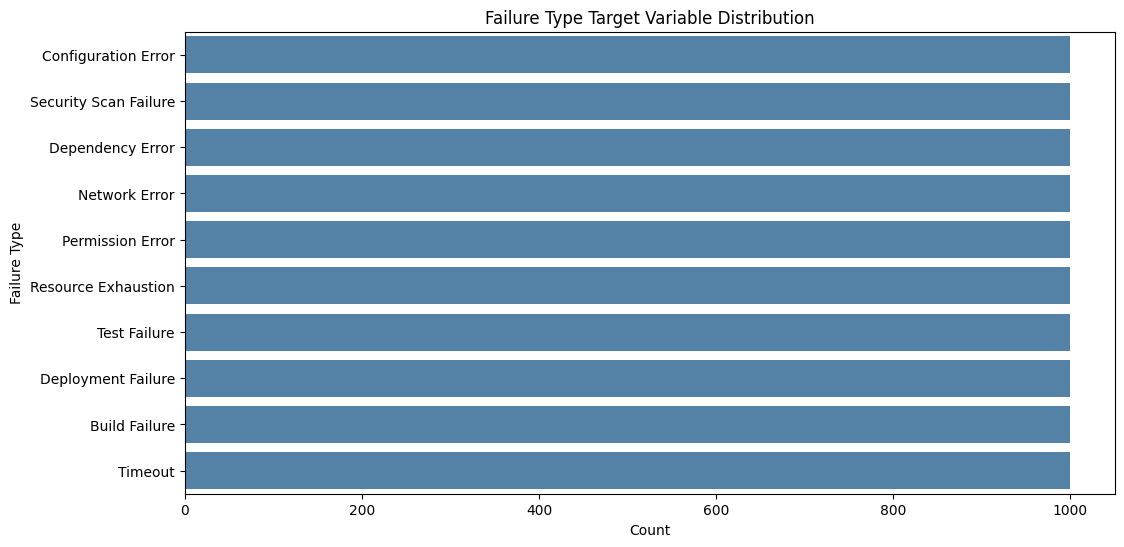

In [14]:
plt.figure(figsize=(12,6))

sns.countplot(
    y='failure_type',
    data=failure_df,
    order=failure_df['failure_type'].value_counts().index,
    color='steelblue'
)

plt.title("Failure Type Target Variable Distribution")
plt.xlabel("Count")
plt.ylabel("Failure Type")
plt.show()

In [15]:
failure_df['raw_log_length'] = failure_df['error_message'].astype(str).str.len()

failure_df['raw_log_length'].describe()

count    10000.000000
mean       216.813900
std         41.192962
min        118.000000
25%        188.000000
50%        215.000000
75%        242.000000
max        397.000000
Name: raw_log_length, dtype: float64

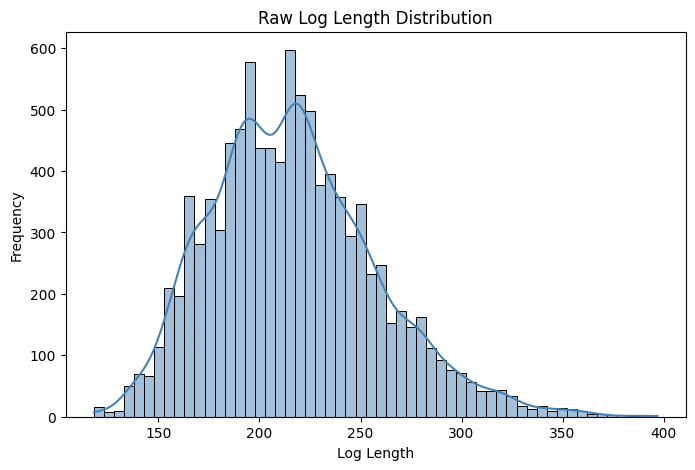

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    failure_df['raw_log_length'],
    kde=True,
    color='steelblue'
)

plt.title("Raw Log Length Distribution")
plt.xlabel("Log Length")
plt.ylabel("Frequency")
plt.show()

In [17]:
failure_df.groupby('failure_type')['error_message'].first()

failure_type
Build Failure            ##[section]Starting: build | Agent job on Azur...
Configuration Error      ##[section]Starting: deploy | Agent job on Azu...
Dependency Error         Run test job on ubuntu-latest | ##[group]refs/...
Deployment Failure       CircleCI step deploy | working_directory=~/pro...
Network Error            [Pipeline] stage(build) | [Pipeline] sh | apt-...
Permission Error         [Pipeline] stage(build) | [Pipeline] sh | kube...
Resource Exhaustion      CircleCI step test | working_directory=~/proje...
Security Scan Failure    [Pipeline] stage(build) | [Pipeline] sh | triv...
Test Failure             CircleCI step test | working_directory=~/proje...
Timeout                  ##[section]Starting: deploy | Agent job on Azu...
Name: error_message, dtype: str

In [18]:
import re

In [19]:
def clean_log(log_text):
    if log_text is None:
        return ""

    log_text = str(log_text).lower()

    log_text = re.sub(
        r"\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}",
        " ",
        log_text
    )

    log_text = re.sub(
        r"http[s]?://\S+",
        " ",
        log_text
    )

    log_text = re.sub(
        r"\b(?:\d{1,3}\.){3}\d{1,3}\b",
        " ",
        log_text
    )

    log_text = re.sub(
        r"(\/[^\s]+)|([a-zA-Z]:\\[^\s]+)",
        " ",
        log_text
    )

    log_text = re.sub(
        r"0x[a-f0-9]+",
        " ",
        log_text
    )

    log_text = re.sub(
        r"<memory at .*?>",
        " memory_address ",
        log_text
    )

    log_text = re.sub(
        r"\b\d{5,}\b",
        " ",
        log_text
    )

    log_text = re.sub(
        r"\b\d+\b",
        " ",
        log_text
    )

    log_text = re.sub(
        r"[^a-z\s]",
        " ",
        log_text
    )

    log_text = re.sub(
        r"\s+",
        " ",
        log_text
    ).strip()

    return log_text

In [20]:
failure_df['cleaned_log'] = failure_df['error_message'].apply(clean_log)

In [21]:
failure_df[['error_message', 'cleaned_log']].head(10)

,error_message,cleaned_log
0,##[section]Starting: deploy | Agent job on Azu...,section starting deploy agent job on azure pip...
1,[Pipeline] stage(build) | [Pipeline] sh | triv...,pipeline stage build pipeline sh trivy image e...
2,Run test job on ubuntu-latest | ##[group]refs/...,run test job on ubuntu latest group refs pip i...
4,[Pipeline] stage(build) | [Pipeline] sh | apt-...,pipeline stage build pipeline sh apt get updat...
6,[Pipeline] stage(build) | [Pipeline] sh | kube...,pipeline stage build pipeline sh kubectl apply...
8,CircleCI step test | working_directory=~/proje...,circleci step test working directory pytest te...
10,Running with gitlab-runner 17.x | stage=build ...,running with gitlab runner x stage build make ...
16,Run build job on ubuntu-latest | ##[group]refs...,run build job on ubuntu latest group refs kube...
19,Running with gitlab-runner 17.x | stage=test |...,running with gitlab runner x stage test make t...
20,CircleCI step test | working_directory=~/proje...,circleci step test working directory npm test ...


In [22]:
failure_df['cleaned_log_length'] = failure_df['cleaned_log'].str.len()

failure_df['cleaned_log_length'].describe()

count    10000.000000
mean       157.374500
std         29.972812
min         82.000000
25%        134.000000
50%        154.000000
75%        176.000000
max        276.000000
Name: cleaned_log_length, dtype: float64

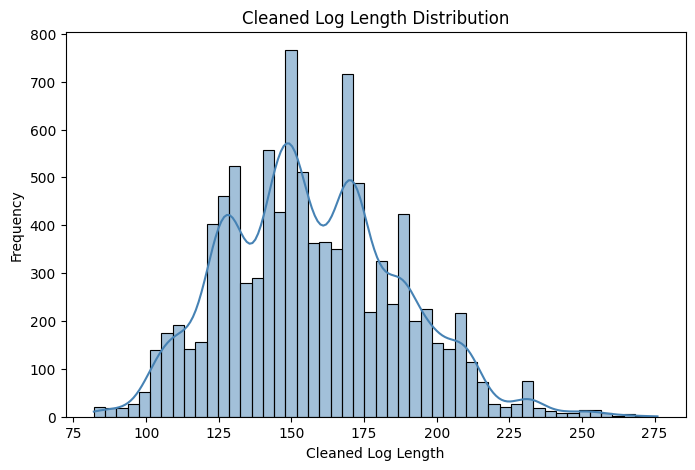

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    failure_df['cleaned_log_length'],
    kde=True,
    color='steelblue'
)

plt.title("Cleaned Log Length Distribution")
plt.xlabel("Cleaned Log Length")
plt.ylabel("Frequency")
plt.show()

In [24]:
print("Unique raw logs:")
print(failure_df['error_message'].nunique())

print("Unique cleaned logs:")
print(failure_df['cleaned_log'].nunique())

Unique raw logs:
8046
Unique cleaned logs:
3553


In [25]:
failure_df.groupby('failure_type')['cleaned_log'].nunique()

failure_type
Build Failure            324
Configuration Error      131
Dependency Error         541
Deployment Failure       481
Network Error            397
Permission Error         284
Resource Exhaustion      135
Security Scan Failure    413
Test Failure             404
Timeout                  491
Name: cleaned_log, dtype: int64

In [26]:
failure_df['word_count'] = failure_df['cleaned_log'].str.split().str.len()

failure_df['word_count'].describe()

count    10000.000000
mean        24.953300
std          5.070374
min         14.000000
25%         21.000000
50%         24.000000
75%         28.000000
max         45.000000
Name: word_count, dtype: float64

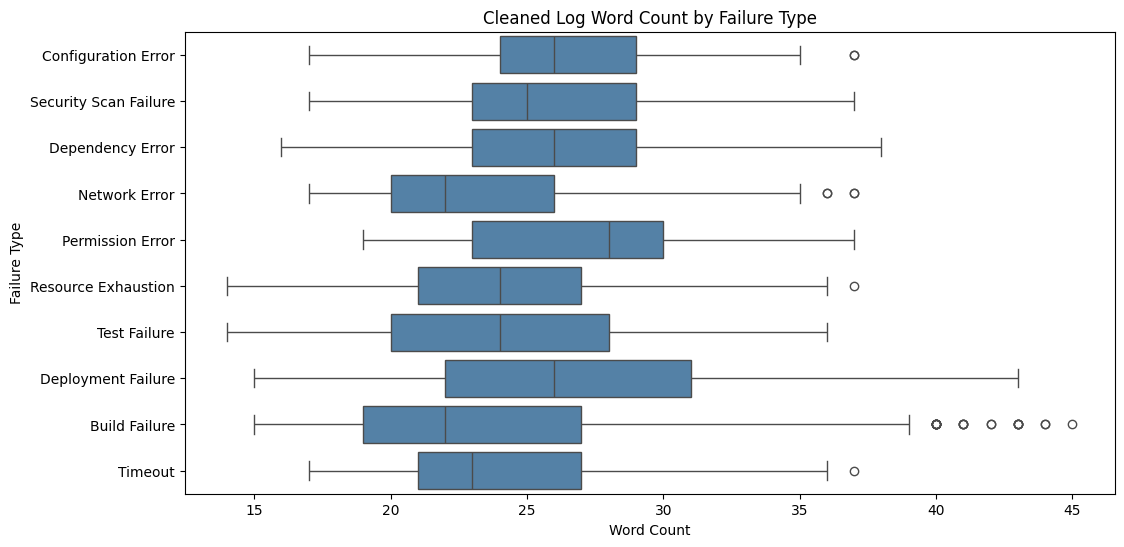

In [27]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=failure_df,
    x='word_count',
    y='failure_type',
    color='steelblue'
)

plt.title("Cleaned Log Word Count by Failure Type")
plt.xlabel("Word Count")
plt.ylabel("Failure Type")
plt.show()

In [28]:
from collections import Counter

In [29]:
all_words = " ".join(failure_df['cleaned_log']).split()

word_counts = Counter(all_words)

top_words = pd.DataFrame(
    word_counts.most_common(20),
    columns=['Word', 'Count']
)

top_words

,Word,Count
0,error,6958
1,build,6868
2,code,6517
3,with,5674
4,test,5625
5,job,5489
6,on,4996
7,deploy,4489
8,exit,4396
9,pipeline,4153


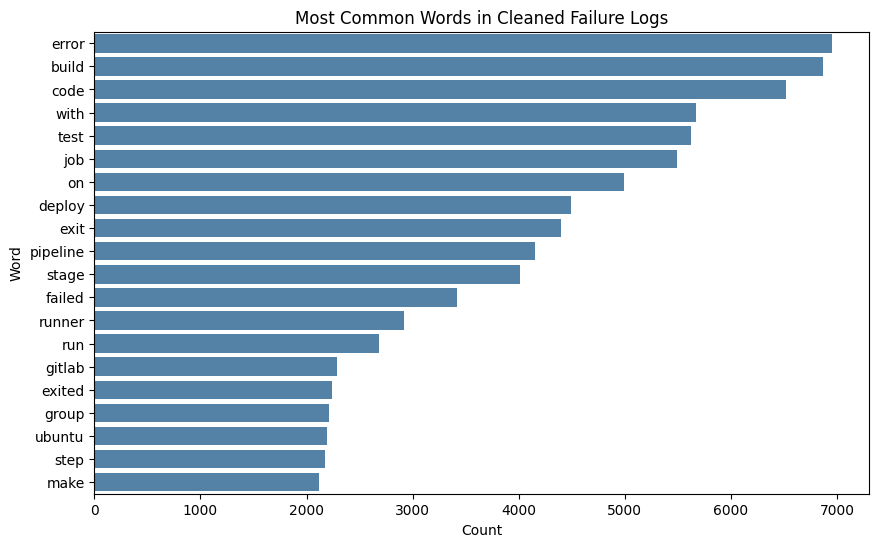

In [30]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words,
    x='Count',
    y='Word',
    color='steelblue'
)

plt.title("Most Common Words in Cleaned Failure Logs")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

In [31]:
print("Empty cleaned logs:")
print((failure_df['cleaned_log'].str.len() == 0).sum())

print("\nFailure type counts:")
print(failure_df['failure_type'].value_counts())

print("\nNumber of failure classes:")
print(failure_df['failure_type'].nunique())

Empty cleaned logs:
0

Failure type counts:
failure_type
Configuration Error      1000
Security Scan Failure    1000
Dependency Error         1000
Network Error            1000
Permission Error         1000
Resource Exhaustion      1000
Test Failure             1000
Deployment Failure       1000
Build Failure            1000
Timeout                  1000
Name: count, dtype: int64

Number of failure classes:
10
